In [10]:
import pandas as pd

df = pd.read_csv('cta-ridership-bus-routes-daily-totals-by-route.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())

(824291, 4)
  route                     date daytype  rides
0     1  2019-06-28T00:00:00.000       W   1476
1     1  2019-06-27T00:00:00.000       W   2007
2     1  2019-06-26T00:00:00.000       W   1748
3     1  2019-06-25T00:00:00.000       W   1927
4     1  2019-06-24T00:00:00.000       W   1727
['route', 'date', 'daytype', 'rides']
route      object
date       object
daytype    object
rides       int64
dtype: object
route      0
date       0
daytype    0
rides      0
dtype: int64


In [11]:
print(df.columns.tolist())
print(df.head())
print(df.shape)

['route', 'date', 'daytype', 'rides']
  route                     date daytype  rides
0     1  2019-06-28T00:00:00.000       W   1476
1     1  2019-06-27T00:00:00.000       W   2007
2     1  2019-06-26T00:00:00.000       W   1748
3     1  2019-06-25T00:00:00.000       W   1927
4     1  2019-06-24T00:00:00.000       W   1727
(824291, 4)


In [12]:
import pandas as pd

# fix the date column - strip the timestamp part
df['date'] = pd.to_datetime(df['date']).dt.date
df['date'] = pd.to_datetime(df['date'])

# extract time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday

# encode daytype
df['is_weekend'] = df['daytype'].isin(['A', 'U']).astype(int)

# check your work
print(df.head())
print(df.dtypes)
print(df.shape)

  route       date daytype  rides  year  month  day  day_of_week  is_weekend
0     1 2019-06-28       W   1476  2019      6   28            4           0
1     1 2019-06-27       W   2007  2019      6   27            3           0
2     1 2019-06-26       W   1748  2019      6   26            2           0
3     1 2019-06-25       W   1927  2019      6   25            1           0
4     1 2019-06-24       W   1727  2019      6   24            0           0
route                  object
date           datetime64[ns]
daytype                object
rides                   int64
year                    int32
month                   int32
day                     int32
day_of_week             int32
is_weekend              int64
dtype: object
(824291, 9)


In [13]:
# check your transit data date range
print("Transit date range:", df['date'].min(), "to", df['date'].max())

# check rides distribution
print("\nRides stats:")
print(df['rides'].describe())

# top 10 busiest routes
print("\nTop 10 busiest routes:")
print(df.groupby('route')['rides'].mean().sort_values(ascending=False).head(10))

Transit date range: 2001-01-01 00:00:00 to 2019-06-30 00:00:00

Rides stats:
count    824291.000000
mean       6512.523138
std        6470.979928
min           0.000000
25%        1466.000000
50%        4189.000000
75%        9888.000000
max       45177.000000
Name: rides, dtype: float64

Top 10 busiest routes:
route
79    26810.430200
9     23663.829312
66    19971.955292
4     19682.818061
49    19641.189489
77    18794.847076
22    18199.418209
8     18124.710733
3     18110.777646
53    17978.098446
Name: rides, dtype: float64


In [14]:
from meteostat import Point, Daily
from datetime import datetime
import pandas as pd

# Chicago coordinates
chicago = Point(41.8781, -87.6298)

# date range matching your transit data
start = datetime(2001, 1, 1)
end = datetime(2019, 6, 28)

# fetch daily weather
weather = Daily(chicago, start, end)
weather = weather.fetch()
weather = weather.reset_index()

# rename columns to match what we need
weather = weather.rename(columns={
    'time': 'date',
    'tmax': 'TMAX',
    'tmin': 'TMIN',
    'prcp': 'PRCP',
    'snow': 'SNOW',
    'wspd': 'AWND'
})

# keep relevant columns
weather = weather[['date', 'TMAX', 'TMIN', 'PRCP', 'SNOW', 'AWND']]
weather['date'] = pd.to_datetime(weather['date'])

print(weather.shape)
print(weather.head())
print(weather.isnull().sum())

(6753, 6)
        date  TMAX  TMIN  PRCP  SNOW  AWND
0 2001-01-01  -3.3 -10.6   0.0  41.0  11.8
1 2001-01-02  -6.1 -13.9   0.0  38.0  13.8
2 2001-01-03  -2.2 -13.9   0.0  38.0  20.0
3 2001-01-04   0.0  -5.0   0.0  36.0  18.7
4 2001-01-05   2.8  -4.4   0.0  30.0  21.9
date      0
TMAX      0
TMIN      0
PRCP      1
SNOW    122
AWND      0
dtype: int64


In [15]:
import streamlit as st
import pandas as pd
import joblib
from datetime import datetime

# Load your model (ensure the path is correct in your repo)
try:
    model = joblib.load('models/best_model.pkl')
except:
    st.error("Model file not found. Make sure 'models/best_model.pkl' exists.")

st.set_page_config(page_title="CTA Load Predictor", page_icon="Bus")
st.title("Chicago CTA High Load Predictor")

# --- USER INPUTS ---
with st.sidebar:
    st.header("Trip Details")
    route = st.number_input("Route ID (Encoded)", min_value=1, value=1)
    date = st.date_input("Travel Date", datetime.now())
    
    st.header("Weather Forecast")
    tmax = st.number_input("Max Temp (TMAX)", value=65)
    tmin = st.number_input("Min Temp (TMIN)", value=45)
    prcp = st.number_input("Precipitation (PRCP)", min_value=0.0, value=0.0)
    snow = st.number_input("Snowfall (SNOW)", min_value=0.0, value=0.0)
    awnd = st.number_input("Wind Speed (AWND)", value=10.0)

    st.header("Historical Context")
    rides_lag_1 = st.number_input("Rides Yesterday (Lag 1)", value=1500)
    rides_lag_7 = st.number_input("Rides Last Week (Lag 7)", value=1500)
    rides_rolling_7 = st.number_input("7-Day Avg Rides", value=1500)

# --- FEATURE ENGINEERING ---
# This mirrors the logic in your image_b45cf2.png
month = date.month
day = date.day
day_of_week = date.weekday()
is_weekend = 1 if day_of_week >= 5 else 0
is_rainy = 1 if prcp > 0 else 0
is_snowy = 1 if snow > 0 else 0

# Simple season logic
if month in [12, 1, 2]: season = 0
elif month in [3, 4, 5]: season = 1
elif month in [6, 7, 8]: season = 2
else: season = 3

# Prepare the data for the model
input_data = pd.DataFrame([[
    month, day, day_of_week, is_weekend, tmax, tmin, prcp, snow, awnd, 
    is_rainy, is_snowy, route, season, rides_lag_1, rides_lag_7, rides_rolling_7
]], columns=[
    'month', 'day', 'day_of_week', 'is_weekend', 'TMAX', 'TMIN', 'PRCP', 'SNOW', 'AWND', 
    'is_rainy', 'is_snowy', 'route_encoded', 'season', 'rides_lag_1', 'rides_lag_7', 'rides_rolling_7'
])

# --- PREDICTION ---
if st.button("Predict Load Status"):
    prediction = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]
    
    if prediction == 1:
        st.error(f"⚠️ **HIGH LOAD PREDICTED** (Probability: {prob:.1%})")
        st.write("Expect the route to be over 20% above its average volume.")
    else:
        st.success(f"✅ **NORMAL LOAD PREDICTED** (Probability: {1-prob:.1%})")

2026-05-02 16:49:02.582 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 16:49:02.583 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 16:49:02.963 
  command:

    streamlit run c:\Users\SANIDHYA RAJ\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-02 16:49:02.964 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 16:49:02.964 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 16:49:02.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 16:49:02.966 Thread 'MainThread': missing ScriptRunContext! 

In [16]:
import os

# create the folder if it doesn't exist
os.makedirs('data/processed', exist_ok=True)

# save
merged.to_csv('data/processed/merged_features.csv', index=False)
print("Saved successfully!")
print("Final shape:", merged.shape)


NameError: name 'merged' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# load your saved dataset
df_model = pd.read_csv('data/processed/merged_features.csv')

# define features and target
features = ['month', 'day', 'day_of_week', 'is_weekend', 
            'TMAX', 'TMIN', 'PRCP', 'SNOW', 'AWND', 
            'is_rainy', 'is_snowy']

X = df_model[features]
y = df_model['high_load']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Target distribution:\n", y.value_counts())

# train model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

Training size: (659432, 11)
Testing size: (164859, 11)
Target distribution:
 high_load
0    591059
1    233232
Name: count, dtype: int64

Accuracy: 74.94 %

Detailed report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83    118177
           1       0.58      0.43      0.50     46682

    accuracy                           0.75    164859
   macro avg       0.69      0.65      0.66    164859
weighted avg       0.73      0.75      0.74    164859



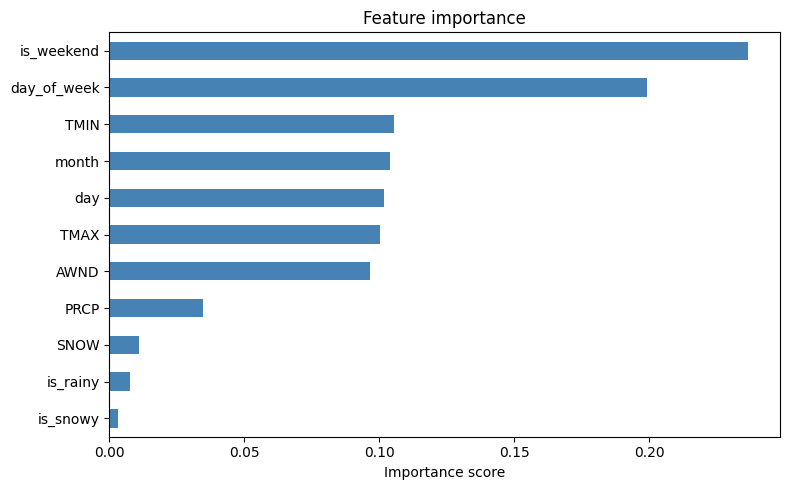

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# feature importance
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature importance')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/random_forest_model.pkl')
print("Model saved!")


Model saved!


In [ ]:
model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced'  # add this
)


In [ ]:
from xgboost import XGBClassifier

xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb2.fit(X_train, y_train)
y_pred_xgb2 = xgb2.predict(X_test)

print("XGBoost + lag accuracy:", round(accuracy_score(y_test, y_pred_xgb2) * 100, 2), "%")
print(classification_report(y_test, y_pred_xgb2))

XGBoost + lag accuracy: 86.67 %
              precision    recall  f1-score   support

           0       0.88      0.95      0.91    118116
           1       0.84      0.66      0.74     46476

    accuracy                           0.87    164592
   macro avg       0.86      0.80      0.82    164592
weighted avg       0.86      0.87      0.86    164592



In [ ]:
# reload clean data
df_model = pd.read_csv('data/processed/merged_features.csv')

# add route encoding
df_model['route_encoded'] = df_model['route'].astype('category').cat.codes

# add season
df_model['season'] = df_model['month'].map({
    12:0, 1:0, 2:0,
    3:1, 4:1, 5:1,
    6:2, 7:2, 8:2,
    9:3, 10:3, 11:3
})

# add lag features
df_model = df_model.sort_values(['route', 'date'])
df_model['rides_lag_1'] = df_model.groupby('route')['rides'].shift(1)
df_model['rides_lag_7'] = df_model.groupby('route')['rides'].shift(7)
df_model['rides_rolling_7'] = df_model.groupby('route')['rides'].transform(
    lambda x: x.shift(1).rolling(7).mean()
)
df_model = df_model.dropna()

# new feature list
features = ['month', 'day', 'day_of_week', 'is_weekend',
            'TMAX', 'TMIN', 'PRCP', 'SNOW', 'AWND',
            'is_rainy', 'is_snowy', 'route_encoded', 'season',
            'rides_lag_1', 'rides_lag_7', 'rides_rolling_7']

X = df_model[features]
y = df_model['high_load']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# train Random Forest with new features
model2 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("Accuracy with lag features:", round(accuracy_score(y_test, y_pred2) * 100, 2), "%")
print(classification_report(y_test, y_pred2))

Accuracy with lag features: 87.04 %
              precision    recall  f1-score   support

           0       0.88      0.95      0.91    118116
           1       0.83      0.68      0.75     46476

    accuracy                           0.87    164592
   macro avg       0.86      0.81      0.83    164592
weighted avg       0.87      0.87      0.87    164592



In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(model2, 'models/best_model.pkl')
print("Model saved!")

Model saved!
